# Dataset Overview: Raman Spectroscopy Bacterial Classification

Initial dataset characterization notebook for the Raman spectroscopy bacterial classification project. The focus is dataset structure, integrity, label semantics, class balance, signal properties, and descriptive split comparison.

## Project Context

The dataset is organized into reference, finetune, test, and clinical splits. This notebook documents how those files are structured, how the label spaces are defined, and how the spectra are distributed across the available splits.

In [19]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.decomposition import PCA

sns.set_style("whitegrid")
plt.rcParams.update({
    "figure.figsize": (14, 6),
    "figure.dpi": 120,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "legend.fontsize": 9,
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

def resolve_project_root() -> Path:
    cwd = Path.cwd()
    candidates = [cwd, cwd.parent, cwd.parent.parent]
    for candidate in candidates:
        if (candidate / "data" / "raw").exists():
            return candidate
    raise FileNotFoundError("Could not locate data/raw from the current working directory.")

PROJECT_ROOT = resolve_project_root()
DATA_DIR = PROJECT_ROOT / "data" / "raw"

SPLIT_SPECS = {
    "reference": {"label_space": "isolate-space", "expected_labels": list(range(30))},
    "finetune": {"label_space": "isolate-space", "expected_labels": list(range(30))},
    "test": {"label_space": "isolate-space", "expected_labels": list(range(30))},
    "2018clinical": {"label_space": "sparse treatment-space", "expected_labels": [0, 2, 3, 5, 6]},
    "2019clinical": {"label_space": "sparse treatment-space", "expected_labels": [0, 2, 3, 5, 6]},
}

dataset_cache = {}
rng = np.random.default_rng(7)
plot_colors = {
    "reference": "#1d3557",
    "finetune": "#457b9d",
    "test": "#e76f51",
    "2018clinical": "#2a9d8f",
    "2019clinical": "#f4a261",
}

def style_axis(axis, title, xlabel="", ylabel=""):
    axis.set_title(title)
    axis.set_xlabel(xlabel)
    axis.set_ylabel(ylabel)
    axis.tick_params(labelsize=9)

## 1. File Discovery

The first check is a simple inventory of all `.npy` files in the raw data directory. This confirms the notebook is operating on the intended dataset package before any deeper inspection.

In [20]:
all_npy_files = sorted(DATA_DIR.glob("*.npy"))

files_df = pd.DataFrame({
    "file_name": [path.name for path in all_npy_files],
    "file_path": [str(path) for path in all_npy_files],
})

display(files_df)

,file_name,file_path
0,wavenumbers.npy,s:\raman-spectral-classifier\data\raw\wavenumb...
1,X_2018clinical.npy,s:\raman-spectral-classifier\data\raw\X_2018cl...
2,X_2019clinical.npy,s:\raman-spectral-classifier\data\raw\X_2019cl...
3,X_finetune.npy,s:\raman-spectral-classifier\data\raw\X_finetu...
4,X_reference.npy,s:\raman-spectral-classifier\data\raw\X_refere...
5,X_test.npy,s:\raman-spectral-classifier\data\raw\X_test.npy
6,y_2018clinical.npy,s:\raman-spectral-classifier\data\raw\y_2018cl...
7,y_2019clinical.npy,s:\raman-spectral-classifier\data\raw\y_2019cl...
8,y_finetune.npy,s:\raman-spectral-classifier\data\raw\y_finetu...
9,y_reference.npy,s:\raman-spectral-classifier\data\raw\y_refere...


## 2. File Inspection

Each array is inspected for shape, dtype, range, and label cardinality when applicable. Label files are summarized with their unique label values so sparse treatment IDs remain visible and interpretable.

In [21]:
inspection_rows = []

for file_path in all_npy_files:
    arr = np.load(file_path)

    row = {
        "file_name": file_path.name,
        "shape": arr.shape,
        "dtype": str(arr.dtype),
        "min": float(np.min(arr)),
        "max": float(np.max(arr)),
        "n_unique_labels": np.nan,
        "unique_labels": np.nan,
    }

    if file_path.name.startswith("y_"):
        unique_labels = np.unique(arr).astype(int)
        row["n_unique_labels"] = int(unique_labels.size)
        row["unique_labels"] = unique_labels.tolist()

    inspection_rows.append(row)

inspection_df = pd.DataFrame(inspection_rows)
display(inspection_df)

,file_name,shape,dtype,min,max,n_unique_labels,unique_labels
0,wavenumbers.npy,"(1000,)",float64,381.98,1792.4,NaN,NaN
1,X_2018clinical.npy,"(10000, 1000)",float64,0.00,1.0,NaN,NaN
2,X_2019clinical.npy,"(2500, 1000)",float64,0.00,1.0,NaN,NaN
3,X_finetune.npy,"(3000, 1000)",float64,0.00,1.0,NaN,NaN
4,X_reference.npy,"(60000, 1000)",float64,0.00,1.0,NaN,NaN
5,X_test.npy,"(3000, 1000)",float64,0.00,1.0,NaN,NaN
6,y_2018clinical.npy,"(10000,)",float64,0.00,6.0,5.0,"[0, 2, 3, 5, 6]"
7,y_2019clinical.npy,"(2500,)",float64,0.00,6.0,5.0,"[0, 2, 3, 5, 6]"
8,y_finetune.npy,"(3000,)",float64,0.00,29.0,30.0,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,..."
9,y_reference.npy,"(60000,)",float64,0.00,29.0,30.0,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,..."


## 3. Dataset Semantic Summary

The isolate-space splits use a contiguous 30-class label set for representation learning. The clinical splits use a sparse treatment ontology with labels `[0, 2, 3, 5, 6]`; the gaps are expected because the clinical label map is inherited from a larger ontology and should not be assumed to be contiguous.

In [22]:
semantic_rows = []

for split_name, split_info in SPLIT_SPECS.items():
    X = np.load(DATA_DIR / f"X_{split_name}.npy")
    y = np.load(DATA_DIR / f"y_{split_name}.npy").astype(int)

    dataset_cache[split_name] = {"X": X, "y": y}

    semantic_rows.append({
        "split": split_name,
        "spectra_shape": X.shape,
        "label_shape": y.shape,
        "n_samples": int(X.shape[0]),
        "signal_length": int(X.shape[1]),
        "n_classes": int(np.unique(y).size),
        "label_space": split_info["label_space"],
    })

semantic_summary_df = pd.DataFrame(semantic_rows)
display(semantic_summary_df)

,split,spectra_shape,label_shape,n_samples,signal_length,n_classes,label_space
0,reference,"(60000, 1000)","(60000,)",60000,1000,30,isolate-space
1,finetune,"(3000, 1000)","(3000,)",3000,1000,30,isolate-space
2,test,"(3000, 1000)","(3000,)",3000,1000,30,isolate-space
3,2018clinical,"(10000, 1000)","(10000,)",10000,1000,5,sparse treatment-space
4,2019clinical,"(2500, 1000)","(2500,)",2500,1000,5,sparse treatment-space


## 4. Class Distribution Analysis

This section verifies that each split is class-balanced and that no expected labels are missing. The bar plots are intentionally split-wise so imbalances or gaps would be visible immediately.

,split,n_classes,min_count,max_count,balanced,missing_classes
0,reference,30,2000,2000,True,[]
1,finetune,30,100,100,True,[]
2,test,30,100,100,True,[]
3,2018clinical,5,2000,2000,True,[]
4,2019clinical,5,500,500,True,[]


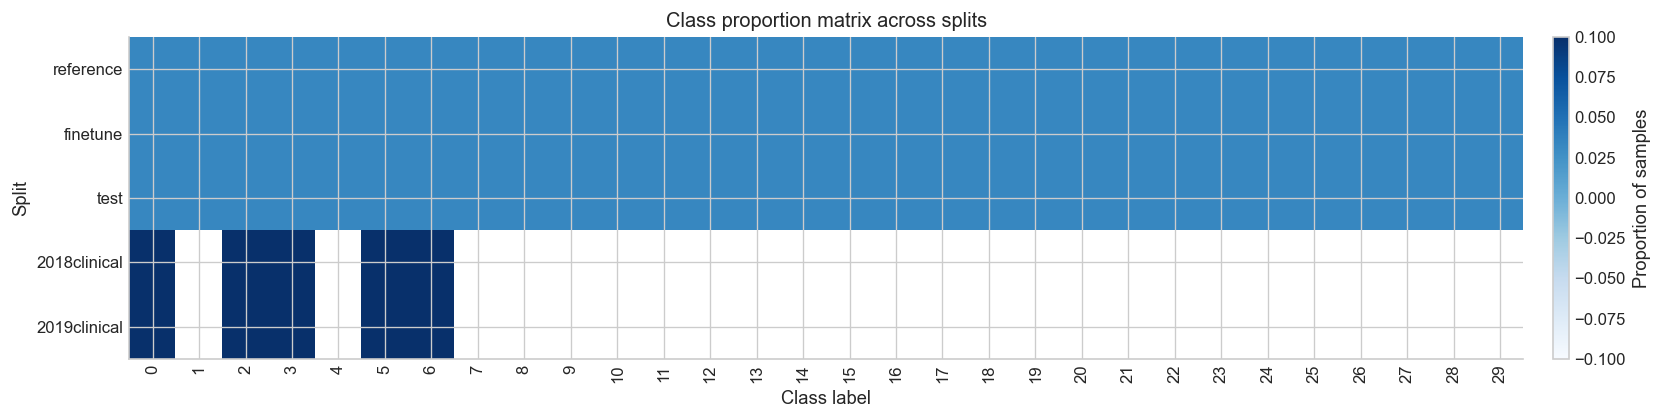

In [23]:
distribution_rows = []
verification_rows = []

for split_name, split_info in SPLIT_SPECS.items():
    y = dataset_cache[split_name]["y"]
    expected_labels = np.array(split_info["expected_labels"], dtype=int)
    values, counts = np.unique(y, return_counts=True)
    count_series = pd.Series(counts, index=values).reindex(expected_labels, fill_value=0).astype(int)

    split_distribution = pd.DataFrame({
        "split": split_name,
        "class_label": count_series.index.astype(int),
        "sample_count": count_series.values,
    })
    distribution_rows.append(split_distribution)

    missing_classes = expected_labels[count_series.values == 0].astype(int).tolist()
    verification_rows.append({
        "split": split_name,
        "n_classes": int(count_series.size),
        "min_count": int(count_series.min()),
        "max_count": int(count_series.max()),
        "balanced": bool(count_series.min() == count_series.max()),
        "missing_classes": missing_classes,
    })

distribution_df = pd.concat(distribution_rows, ignore_index=True)
verification_df = pd.DataFrame(verification_rows)
display(verification_df)

distribution_matrix = distribution_df.pivot(index="split", columns="class_label", values="sample_count")
distribution_matrix = distribution_matrix.loc[list(SPLIT_SPECS.keys())]
distribution_proportions = distribution_matrix.div(distribution_matrix.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(14, 3.6))
im = ax.imshow(distribution_proportions.values, aspect="auto", cmap="Blues", vmin=0, vmax=distribution_proportions.values.max())
ax.set_title("Class proportion matrix across splits")
ax.set_xlabel("Class label")
ax.set_ylabel("Split")
ax.set_xticks(np.arange(distribution_proportions.shape[1]))
ax.set_xticklabels(distribution_proportions.columns.astype(int), rotation=90)
ax.set_yticks(np.arange(distribution_proportions.shape[0]))
ax.set_yticklabels(distribution_proportions.index)

colorbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
colorbar.set_label("Proportion of samples")

plt.tight_layout()
plt.show()

## 5. Wavenumber Analysis

The Raman axis should be consistent with the spectral length used by every split. This check documents the shift range, spacing uniformity, and alignment between the axis vector and the spectra. The stored axis is descending, so the spacing statistics are negative by convention.

,vector_shape,min_shift,max_shift,mean_spacing,std_spacing,min_spacing,max_spacing,aligned_with_spectra
0,"(1000,)",381.98,1792.4,-1.411832,0.085423,-1.56,-1.2,True


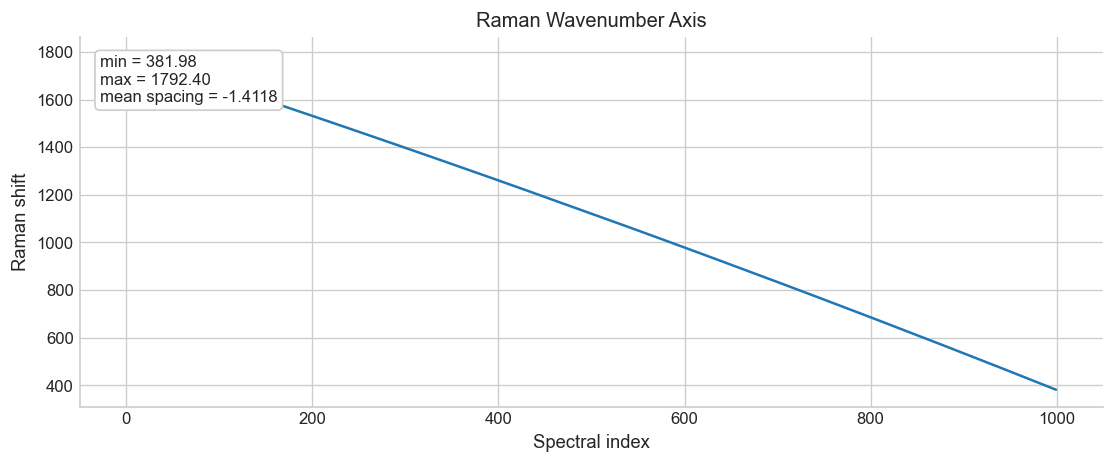

In [24]:
wavenumbers = np.load(DATA_DIR / "wavenumbers.npy")
spacing = np.diff(wavenumbers)
reference_length = dataset_cache["reference"]["X"].shape[1]

wavenumber_df = pd.DataFrame([
    {
        "vector_shape": wavenumbers.shape,
        "min_shift": float(wavenumbers.min()),
        "max_shift": float(wavenumbers.max()),
        "mean_spacing": float(spacing.mean()),
        "std_spacing": float(spacing.std()),
        "min_spacing": float(spacing.min()),
        "max_spacing": float(spacing.max()),
        "aligned_with_spectra": bool(wavenumbers.size == reference_length),
    }
])

display(wavenumber_df)

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(np.arange(wavenumbers.size), wavenumbers, color="#1f77b4", linewidth=1.5)
ax.set_title("Raman Wavenumber Axis")
ax.set_xlabel("Spectral index")
ax.set_ylabel("Raman shift")
ax.text(0.02, 0.95, f"min = {wavenumbers.min():.2f}\nmax = {wavenumbers.max():.2f}\nmean spacing = {spacing.mean():.4f}",
        transform=ax.transAxes, va="top", ha="left",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="0.8"))
plt.show()

## 6. Raw Spectral Visualization

Inspect representative spectra from the reference split to build intuition about general spectral morphology and within-class variability.

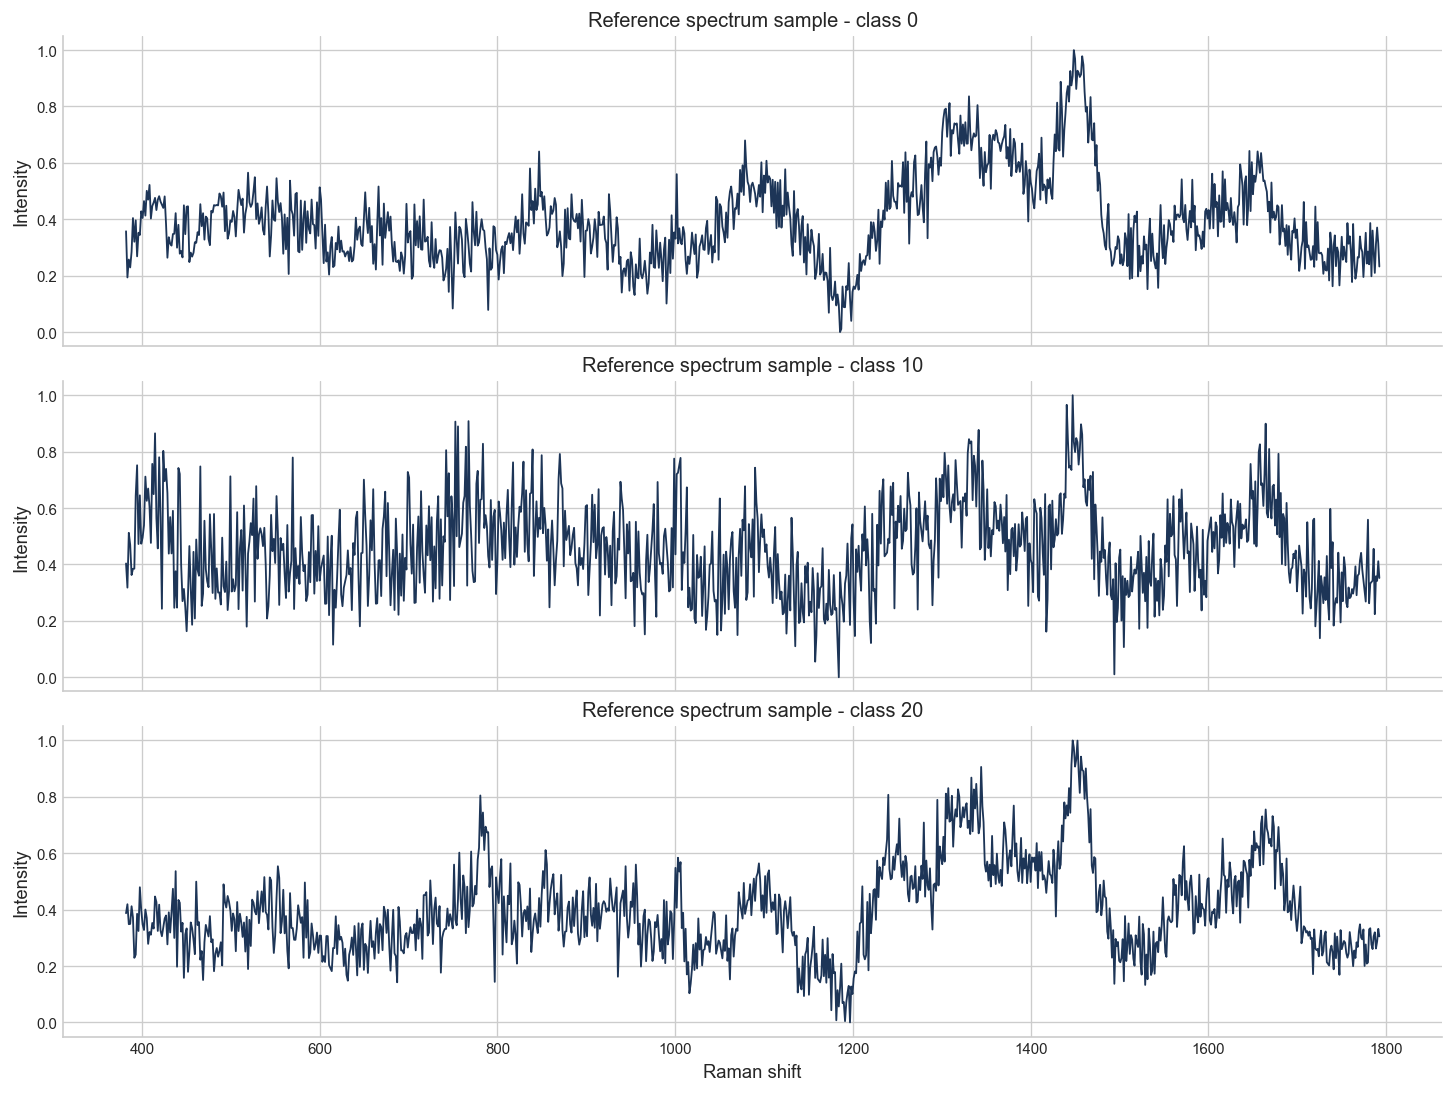

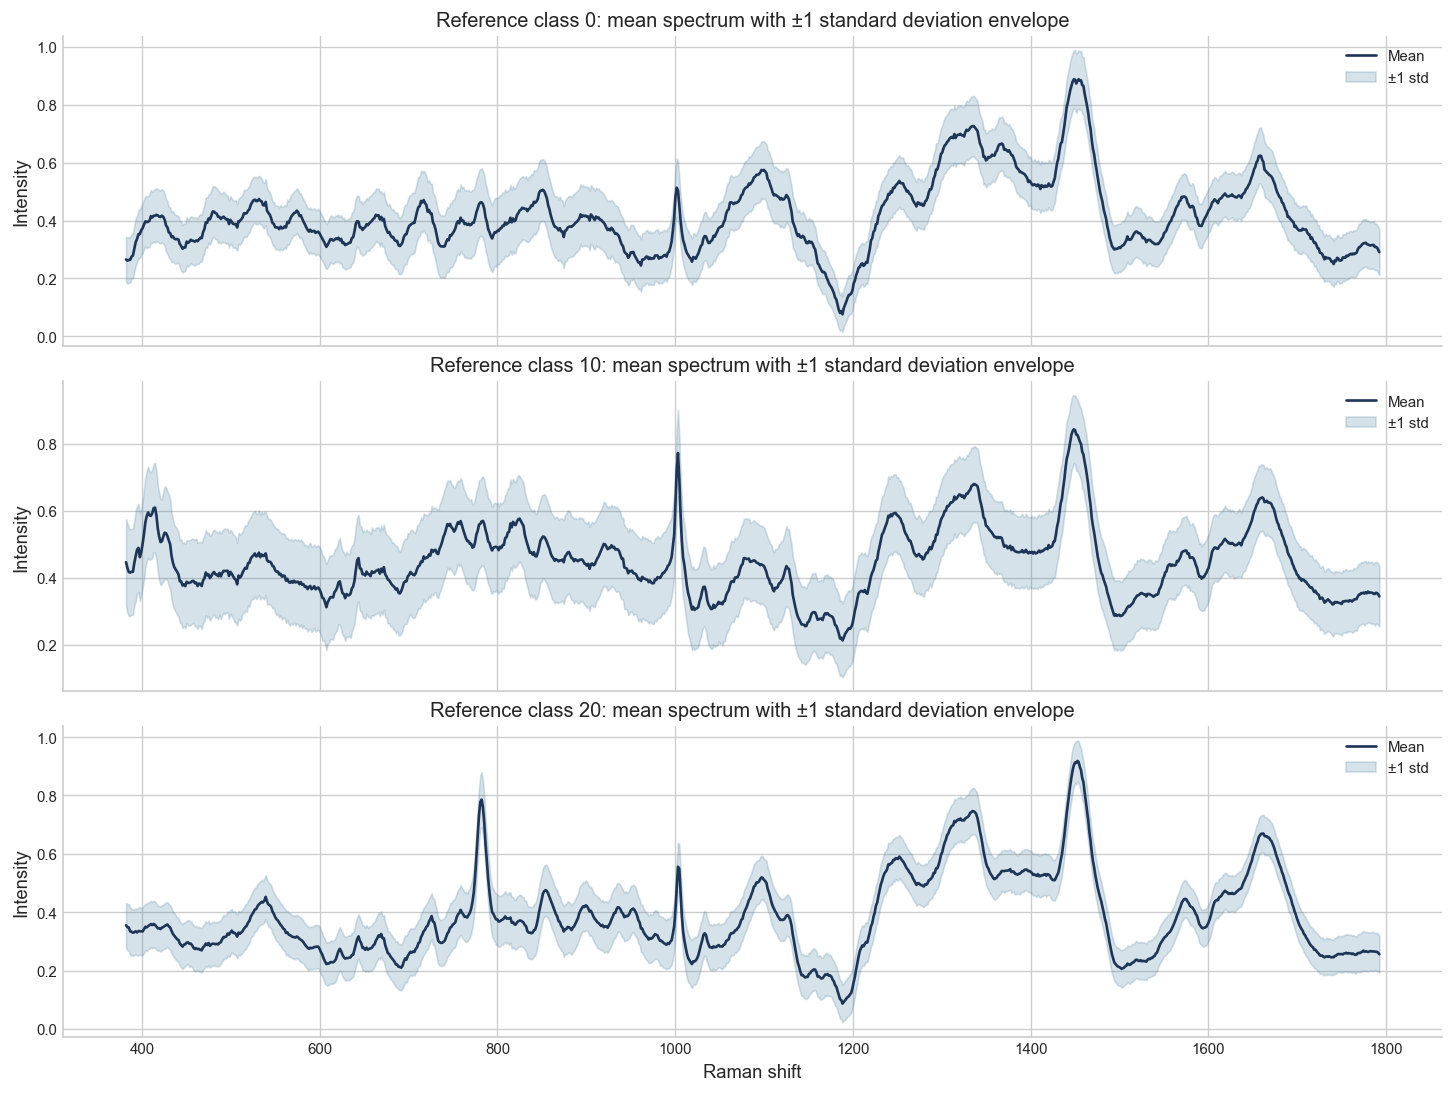

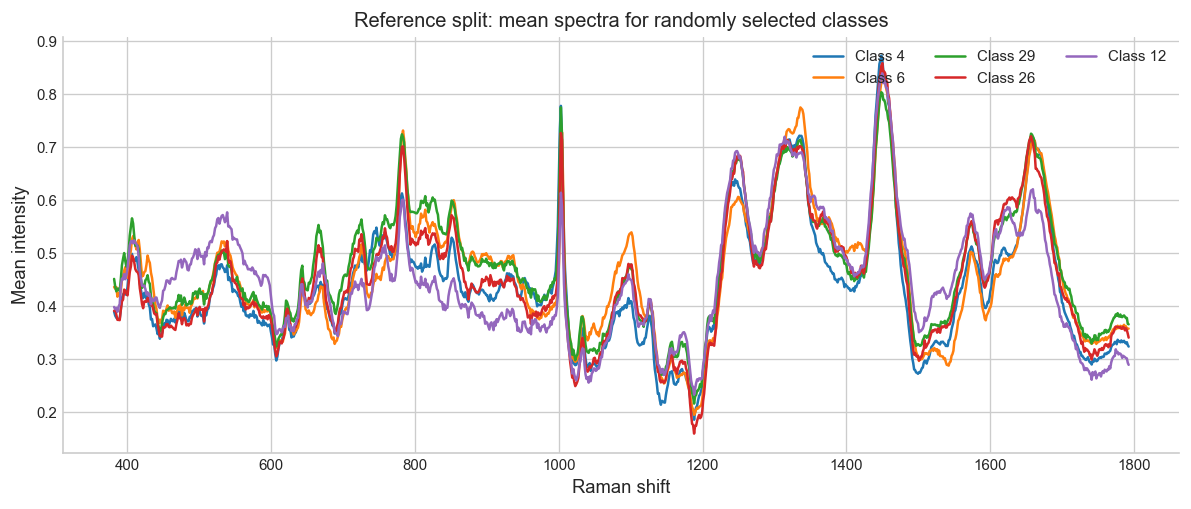

In [28]:
X_ref = dataset_cache["reference"]["X"]
y_ref = dataset_cache["reference"]["y"]

representative_classes = [0, 10, 20]
fig, axes = plt.subplots(len(representative_classes), 1, figsize=(12, 9), sharex=True, constrained_layout=True)
for axis, class_id in zip(axes, representative_classes):
    class_indices = np.flatnonzero(y_ref == class_id)
    chosen_index = rng.choice(class_indices)
    axis.plot(wavenumbers, X_ref[chosen_index], color=plot_colors["reference"], linewidth=1.1)
    style_axis(axis, f"Reference spectrum sample - class {class_id}", "", "Intensity")
axes[-1].set_xlabel("Raman shift")
plt.show()

fig, axes = plt.subplots(len(representative_classes), 1, figsize=(12, 9), sharex=True, constrained_layout=True)
for axis, class_id in zip(axes, representative_classes):
    class_spectra = X_ref[y_ref == class_id]
    class_mean = class_spectra.mean(axis=0)
    class_std = class_spectra.std(axis=0)
    axis.plot(wavenumbers, class_mean, color=plot_colors["reference"], linewidth=1.6, label="Mean")
    axis.fill_between(wavenumbers, class_mean - class_std, class_mean + class_std, color=plot_colors["finetune"], alpha=0.22, label="±1 std")
    style_axis(axis, f"Reference class {class_id}: mean spectrum with ±1 standard deviation envelope", "", "Intensity")
    axis.legend(loc="upper right", frameon=False)
axes[-1].set_xlabel("Raman shift")
plt.show()

random_class_ids = rng.choice(np.unique(y_ref), size=5, replace=False)
fig, ax = plt.subplots(figsize=(12, 4.5))
for class_id in random_class_ids:
    class_spectra = X_ref[y_ref == class_id]
    class_mean = class_spectra.mean(axis=0)
    ax.plot(wavenumbers, class_mean, linewidth=1.5, label=f"Class {class_id}")
style_axis(ax, "Reference split: mean spectra for randomly selected classes", "Raman shift", "Mean intensity")
ax.legend(ncol=3, frameon=False, loc="upper right")
plt.show()

## 7. Signal Quality & Normalization

Check that the raw spectra are finite, consistently scaled, and numerically well formed across splits.

,split,n_samples,n_features,all_finite,min_intensity,max_intensity,mean_intensity,std_intensity,zero_fraction,duplicate_spectra,label_count
0,reference,60000,1000,True,0.0,1.0,0.427644,0.180745,0.000954,0,30
1,finetune,3000,1000,True,0.0,1.0,0.424039,0.170879,0.000952,0,30
2,test,3000,1000,True,0.0,1.0,0.425135,0.169145,0.000936,0,30
3,2018clinical,10000,1000,True,0.0,1.0,0.462201,0.160661,0.000929,0,5
4,2019clinical,2500,1000,True,0.0,1.0,0.445641,0.162833,0.000920,0,5


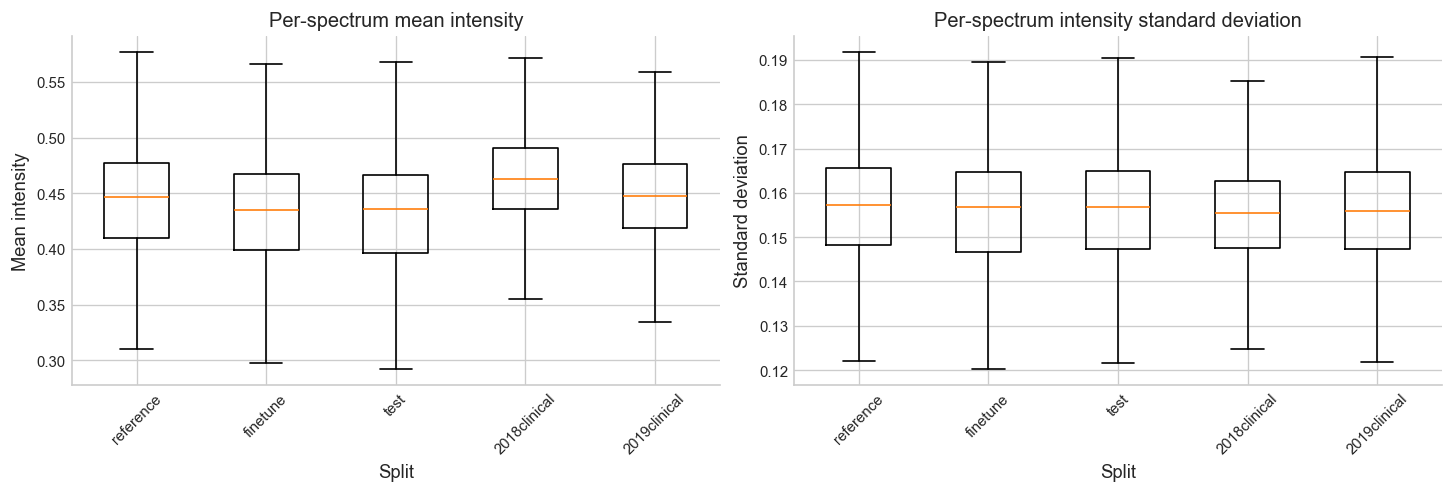

In [29]:
signal_rows = []
mean_intensity_by_split = []
std_intensity_by_split = []

for split_name in SPLIT_SPECS:
    X = dataset_cache[split_name]["X"]
    y = dataset_cache[split_name]["y"]

    per_sample_mean = X.mean(axis=1)
    per_sample_std = X.std(axis=1)

    signal_rows.append({
        "split": split_name,
        "n_samples": int(X.shape[0]),
        "n_features": int(X.shape[1]),
        "all_finite": bool(np.isfinite(X).all()),
        "min_intensity": float(X.min()),
        "max_intensity": float(X.max()),
        "mean_intensity": float(X.mean()),
        "std_intensity": float(X.std()),
        "zero_fraction": float(np.mean(X == 0.0)),
        "duplicate_spectra": int(X.shape[0] - np.unique(X, axis=0).shape[0]),
        "label_count": int(np.unique(y).size),
    })

    mean_intensity_by_split.append(per_sample_mean)
    std_intensity_by_split.append(per_sample_std)

signal_quality_df = pd.DataFrame(signal_rows)
display(signal_quality_df)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
axes[0].boxplot(mean_intensity_by_split, tick_labels=list(SPLIT_SPECS.keys()), showfliers=False)
style_axis(axes[0], "Per-spectrum mean intensity", "Split", "Mean intensity")
axes[0].tick_params(axis="x", rotation=45)
axes[1].boxplot(std_intensity_by_split, tick_labels=list(SPLIT_SPECS.keys()), showfliers=False)
style_axis(axes[1], "Per-spectrum intensity standard deviation", "Split", "Standard deviation")
axes[1].tick_params(axis="x", rotation=45)
plt.show()

## 8. Global Split Comparison

Compare the splits descriptively at a global level using mean spectra, variability envelopes, and a low-dimensional visualization of sampled spectra.

,split,n_samples,mean_intensity,std_intensity
0,reference,60000,0.427644,0.180745
1,finetune,3000,0.424039,0.170879
2,test,3000,0.425135,0.169145
3,2018clinical,10000,0.462201,0.160661
4,2019clinical,2500,0.445641,0.162833


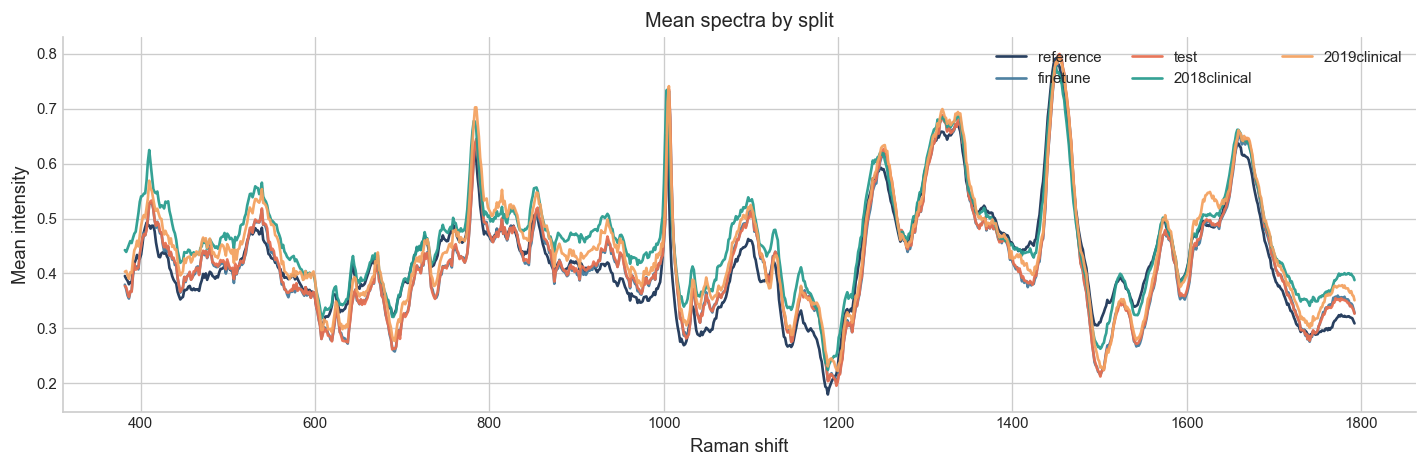

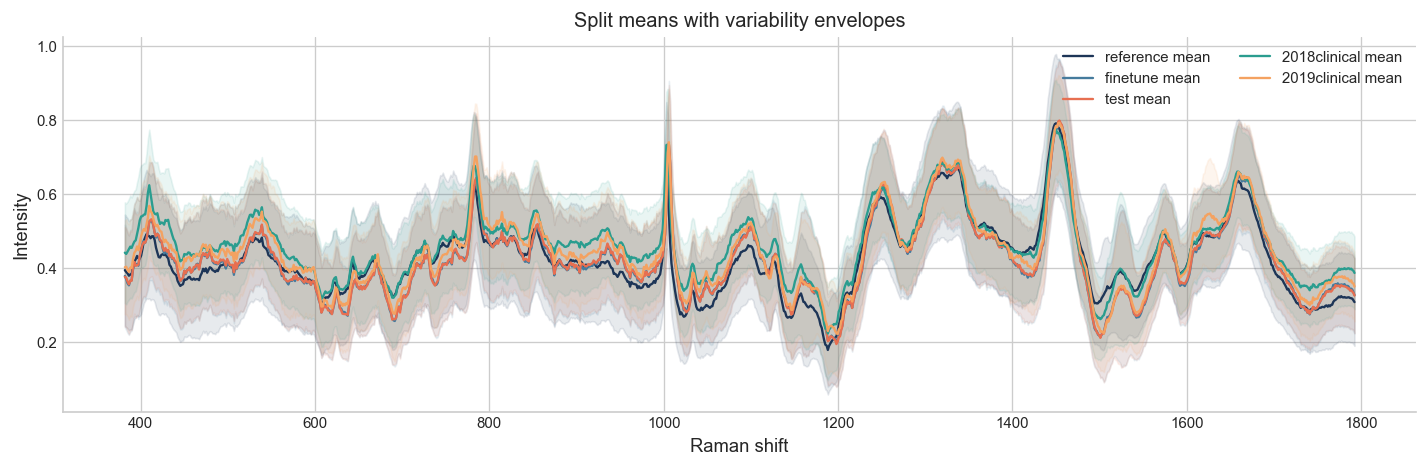

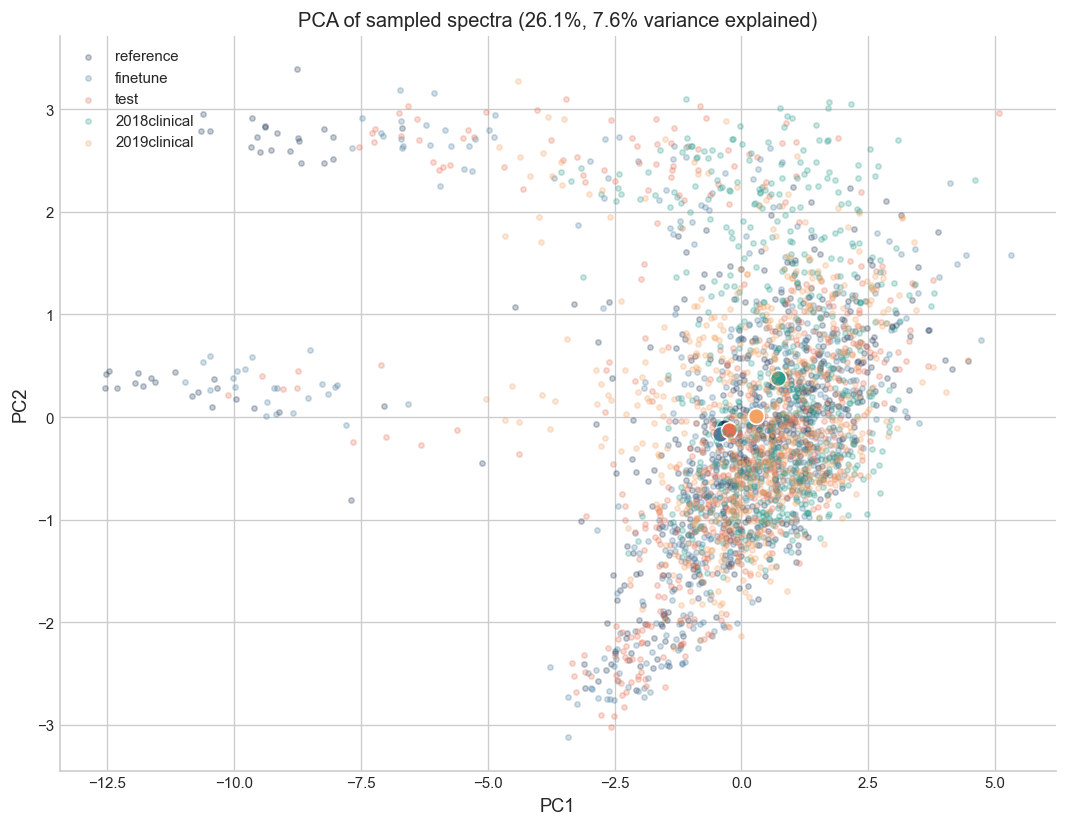

In [27]:
split_order = list(SPLIT_SPECS.keys())
mean_spectra = {}
sampled_spectra = []
split_summary_rows = []

for split_name in split_order:
    X = dataset_cache[split_name]["X"]
    mean_spectra[split_name] = X.mean(axis=0)
    split_summary_rows.append({
        "split": split_name,
        "n_samples": int(X.shape[0]),
        "mean_intensity": float(X.mean()),
        "std_intensity": float(X.std()),
    })
    sample_size = min(600, X.shape[0])
    sample_indices = rng.choice(X.shape[0], size=sample_size, replace=False)
    sampled_spectra.append(X[sample_indices])

split_summary_df = pd.DataFrame(split_summary_rows)
display(split_summary_df)

fig, ax = plt.subplots(figsize=(12, 4))
for split_name in split_order:
    ax.plot(wavenumbers, mean_spectra[split_name], label=split_name, color=plot_colors[split_name], linewidth=1.6, alpha=0.95)
style_axis(ax, "Mean spectra by split", "Raman shift", "Mean intensity")
ax.legend(ncol=3, frameon=False, loc="upper right")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 4))
for split_name in split_order:
    split_array = dataset_cache[split_name]["X"]
    split_mean = split_array.mean(axis=0)
    split_std = split_array.std(axis=0)
    ax.plot(wavenumbers, split_mean, color=plot_colors[split_name], linewidth=1.4, label=f"{split_name} mean")
    ax.fill_between(wavenumbers, split_mean - split_std, split_mean + split_std, color=plot_colors[split_name], alpha=0.10)
style_axis(ax, "Split means with variability envelopes", "Raman shift", "Intensity")
ax.legend(ncol=2, frameon=False, loc="upper right")
plt.tight_layout()
plt.show()

X_pca = np.vstack(sampled_spectra)
pca = PCA(n_components=2, random_state=7)
X_pca_2d = pca.fit_transform(X_pca)

fig, ax = plt.subplots(figsize=(9, 7))
start = 0
for split_name, sample_array in zip(split_order, sampled_spectra):
    end = start + sample_array.shape[0]
    coords = X_pca_2d[start:end]
    ax.scatter(coords[:, 0], coords[:, 1], s=10, alpha=0.25, label=split_name, color=plot_colors[split_name])
    centroid = coords.mean(axis=0)
    ax.scatter(centroid[0], centroid[1], s=90, color=plot_colors[split_name], edgecolor="white", linewidth=1.0)
    start = end
style_axis(ax, f"PCA of sampled spectra ({pca.explained_variance_ratio_[0]:.1%}, {pca.explained_variance_ratio_[1]:.1%} variance explained)", "PC1", "PC2")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

## 9. Dataset Characterization Summary

We now understand the dataset structure, signal properties, label semantics, and general spectral morphology.